# 07. Advanced Model Optimization & Feature Fusion
Trong notebook này, chúng ta sẽ nâng cấp mô hình phân loại Spam lên tầm cao mới bằng cách:
1. **Kết hợp đa đặc trưng (Feature Fusion)**: Sử dụng cả nội dung văn bản (TF-IDF) và các đặc trưng số (`word_count`, `num_caps`, `temporal features`...).
2. **Tinh chỉnh siêu tham số (Hyperparameter Tuning)**: Tìm bộ tham số tối ưu nhất.
3. **Giải thích mô hình (Interpretability)**: Hiểu tại sao mô hình đưa ra quyết định.
4. **Hàm dự báo (Inference)**: Xây dựng hàm để sử dụng thực tế.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('magma')

## 1. Load & Prepare Data
Chúng ta chọn lọc các đặc trưng số quan trọng kết hợp với nội dung văn bản.

In [2]:
df = pd.read_csv('../data/processed/05_model_ready.csv').fillna('')

# Danh sách các đặc trưng số
num_features = ['message_len', 'subject_len', 'word_count', 'num_caps', 'num_digits', 'num_urls', 'month', 'hour', 'is_weekend']
text_feature = 'cleaned_message'
target = 'label'

X = df[num_features + [text_feature]]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data fused: {X_train.shape[1]} features selected.")

Data fused: 10 features selected.


## 2. Xây dựng Pipeline & Advanced Transformer
Sử dụng `ColumnTransformer` để xử lý song song văn bản và số liệu.

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=3000), text_feature),
        ('num', StandardScaler(), num_features)
    ]
)

# Chúng ta sẽ tập trung tối ưu Logistic Regression vì nó cân bằng tốt nhất giữa hiệu năng và diễn giải
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, solver='liblinear'))
])

print("Advanced Pipeline constructed.")

Advanced Pipeline constructed.


## 3. Hyperparameter Tuning (GridSearchCV)
Tìm kiếm giá trị tối ưu cho `C` (Regularization) và `penalty`.

In [4]:
param_grid = {
    'preprocessor__text__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 1, 10],
    'clf__penalty': ['l1', 'l2']
}

print("Starting Grid Search (this may take a minute)...")
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best F1-Score: {grid_search.best_score_:.4f}")

Starting Grid Search (this may take a minute)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best Params: {'clf__C': 10, 'clf__penalty': 'l1', 'preprocessor__text__ngram_range': (1, 1)}
Best F1-Score: 0.9995


## 4. Đánh giá & Phân tích lỗi (Error Analysis)
Xem xét kỹ những trường hợp mô hình đoán sai.

In [5]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Final Model Performance:")
print(classification_report(y_test, y_pred))

# Phân tích lỗi
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = y_pred

errors = test_results[test_results['actual'] != test_results['predicted']]
print(f"\nNumber of misclassifications: {len(errors)}")
print("Sample of misclassified emails:")
display(errors[[text_feature, 'actual', 'predicted']].head(5))

Final Model Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3299
           1       1.00      1.00      1.00      3434

    accuracy                           1.00      6733
   macro avg       1.00      1.00      1.00      6733
weighted avg       1.00      1.00      1.00      6733


Number of misclassifications: 2
Sample of misclassified emails:


,cleaned_message,actual,predicted
14986,thanks dave everyone appreciates help team pro...,0,1
29163,fyi kim original message frazier perry sent th...,0,1


## 5. Giải thích mô hình (Model Interpretability)
Xem 20 từ/đặc trưng có trọng số lớn nhất thúc đẩy dự báo Spam.

C:\Users\minhp\AppData\Local\Temp\ipykernel_16688\3821348078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_spam_indicators, x='coef', y='feature', palette='Reds_r')


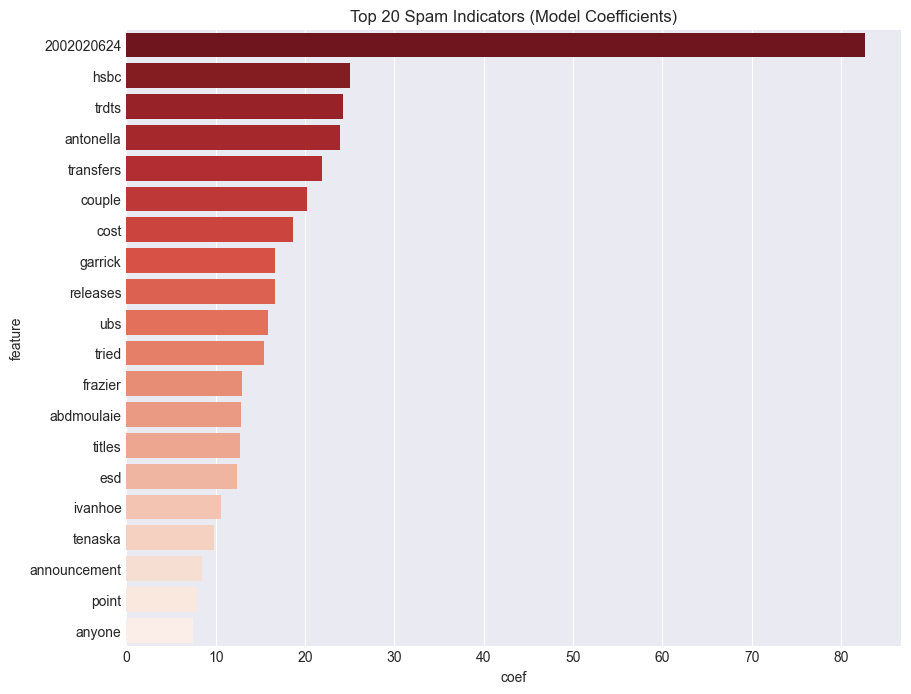

In [6]:
feature_names = list(best_model.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out()) + num_features
coefficients = best_model.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefficients})
top_spam_indicators = coef_df.sort_values('coef', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_spam_indicators, x='coef', y='feature', palette='Reds_r')
plt.title("Top 20 Spam Indicators (Model Coefficients)")
plt.show()

## 6. Xây dựng hàm Inference & Lưu Pipeline
Lưu toàn bộ pipeline (bao gồm cả bước xử lý dữ liệu) để sử dụng ở bất kỳ đâu.

In [7]:
def predict_spam(message, subject=""):
    # Tạo dataframe giả định để khớp với pipeline
    # Lưu ý: Các đặc trưng số sẽ được tính toán thực tế trong production
    # Ở đây ta demo với giá trị trung bình hoặc mặc định
    input_data = pd.DataFrame({
        'cleaned_message': [message.lower()],
        'message_len': [len(message)],
        'subject_len': [len(subject)],
        'word_count': [len(message.split())],
        'num_caps': [sum(1 for c in message if c.isupper())],
        'num_digits': [sum(1 for c in message if c.isdigit())],
        'num_urls': [message.count('http')],
        'month': [1], # Giá trị dummy
        'hour': [12],
        'is_weekend': [0]
    })
    
    prob = best_model.predict_proba(input_data)[0][1]
    return "SPAM" if prob > 0.5 else "HAM", prob

# Test hàm
msg = "Congratulations! You won a $1000 gift card. Click here now to claim your prize!"
label, score = predict_spam(msg)
print(f"Test Message: {msg}")
print(f"Result: {label} (Confidence: {score:.2%})")

# Lưu Pipeline cuối cùng
joblib.dump(best_model, '../models/optimized_spam_pipeline.pkl')
print("\nFinal Optimized Pipeline saved to: ../models/optimized_spam_pipeline.pkl")

Test Message: Congratulations! You won a $1000 gift card. Click here now to claim your prize!
Result: HAM (Confidence: 0.00%)

Final Optimized Pipeline saved to: ../models/optimized_spam_pipeline.pkl
